In [1]:
import pandas as pd
from xgboost import XGBClassifier   #, plot_importance
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, confusion_matrix, ConfusionMatrixDisplay,RocCurveDisplay # cleanup what's not needed
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [2]:
df = pd.read_csv('diabetes_binary2.csv' ,  header = 0 )   # read the data file
df.shape                                               # display the number of rows and columns in file

(70692, 23)

In [5]:
pd.set_option('display.max_rows', 100)     #limit the number of rows displayed to 100
pd.set_option('display.max_columns', None)  #display all columns
df.head(10)                                     ###?? fix data types

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,bmiage
0,0,1,0,1,26,0,0,0,1,0,1,0,1,0,3,5,30,0,1,4,6,8,104
1,0,1,1,1,26,1,1,0,0,1,0,0,1,0,3,0,0,0,1,12,6,8,312
2,0,0,0,1,26,0,0,0,1,1,1,0,1,0,1,0,10,0,1,13,6,8,338
3,0,1,1,1,28,1,0,0,1,1,1,0,1,0,3,0,3,0,1,11,6,8,308
4,0,0,0,1,29,1,0,0,1,1,1,0,1,0,2,0,0,0,0,8,5,8,232
5,0,0,0,1,18,0,0,0,1,1,1,0,0,0,2,7,0,0,0,1,4,7,18
6,0,0,1,1,26,1,0,0,1,1,1,1,1,0,1,0,0,0,1,13,5,6,338
7,0,0,0,1,31,1,0,0,0,1,1,0,1,0,4,0,0,0,1,6,4,3,186
8,0,0,0,1,32,0,0,0,1,1,1,0,1,0,3,0,0,0,0,3,6,8,96
9,0,0,0,1,27,1,0,0,0,1,1,0,1,0,3,0,6,0,1,6,4,4,162


In [6]:
df = df.astype("Int64")  #correct datatypes which is displaying as float
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       70692 non-null  Int64
 1   HighBP                70692 non-null  Int64
 2   HighChol              70692 non-null  Int64
 3   CholCheck             70692 non-null  Int64
 4   BMI                   70692 non-null  Int64
 5   Smoker                70692 non-null  Int64
 6   Stroke                70692 non-null  Int64
 7   HeartDiseaseorAttack  70692 non-null  Int64
 8   PhysActivity          70692 non-null  Int64
 9   Fruits                70692 non-null  Int64
 10  Veggies               70692 non-null  Int64
 11  HvyAlcoholConsump     70692 non-null  Int64
 12  AnyHealthcare         70692 non-null  Int64
 13  NoDocbcCost           70692 non-null  Int64
 14  GenHlth               70692 non-null  Int64
 15  MentHlth              70692 non-null  Int64
 16  Phys

In [7]:
## change data to integers????????????????
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,bmiage
0,0,1,0,1,26,0,0,0,1,0,1,0,1,0,3,5,30,0,1,4,6,8,104
1,0,1,1,1,26,1,1,0,0,1,0,0,1,0,3,0,0,0,1,12,6,8,312
2,0,0,0,1,26,0,0,0,1,1,1,0,1,0,1,0,10,0,1,13,6,8,338
3,0,1,1,1,28,1,0,0,1,1,1,0,1,0,3,0,3,0,1,11,6,8,308
4,0,0,0,1,29,1,0,0,1,1,1,0,1,0,2,0,0,0,0,8,5,8,232


In [8]:
df.duplicated().sum()       #check for duplicated row , need to follow up on where to drop them???????


1635

In [9]:
df.drop_duplicates(inplace=True)   #remove duplicated rows
df.shape

(69057, 23)

In [10]:
df.dropna(axis ='index', how='all', subset= ['Diabetes_binary'], inplace=True) #check for nulls in diabestes column
(69057, 22)

(69057, 22)

In [11]:
df[df.isna().any(axis=1)]  # check for nulls across the board

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,bmiage


In [12]:
df.isna().sum()  # check if there is any missing data

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
bmiage                  0
dtype: int64

In [13]:
df["Diabetes_binary"].value_counts()  #ch if dataset is balanced  ?????????????????????

Diabetes_binary
1    35097
0    33960
Name: count, dtype: Int64

In [14]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,bmiage
count,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0,69057.0
mean,0.508232,0.571224,0.531329,0.974803,29.955834,0.481935,0.063643,0.150875,0.696483,0.605659,0.78412,0.043515,0.953908,0.096138,2.863692,3.840103,5.945306,0.258612,0.456464,8.604037,4.900285,5.651332,256.819077
std,0.499936,0.494905,0.499021,0.156723,7.147972,0.499677,0.244118,0.35793,0.45978,0.488712,0.411434,0.204014,0.209687,0.294782,1.10795,8.231164,10.139113,0.437875,0.498105,2.858284,1.029338,2.175608,100.098621
min,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,16.0
25%,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,7.0,4.0,4.0,192.0
50%,1.0,1.0,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,9.0,5.0,6.0,260.0
75%,1.0,1.0,1.0,1.0,33.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,4.0,3.0,6.0,1.0,1.0,11.0,6.0,8.0,320.0
max,1.0,1.0,1.0,1.0,98.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,30.0,30.0,1.0,1.0,13.0,6.0,8.0,1196.0


In [15]:
df.corr()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,bmiage
Diabetes_binary,1.000000,0.372048,0.281399,0.118900,0.285643,0.075853,0.122727,0.207229,-0.150281,-0.044560,-0.072181,-0.098709,0.027034,0.036145,0.396571,0.080688,0.206868,0.267082,0.042538,0.274550,-0.158522,-0.212846,0.396830
HighBP,0.372048,1.000000,0.308987,0.106593,0.232372,0.078123,0.126869,0.206776,-0.128307,-0.031818,-0.059824,-0.029764,0.039659,0.021802,0.308459,0.058133,0.167821,0.229638,0.037824,0.333721,-0.130037,-0.176360,0.408202
HighChol,0.281399,0.308987,1.000000,0.088231,0.123917,0.086522,0.098166,0.178207,-0.084469,-0.040783,-0.037801,-0.027259,0.034352,0.029976,0.227588,0.079929,0.138266,0.157859,0.013250,0.235779,-0.075364,-0.098712,0.263852
CholCheck,0.118900,0.106593,0.088231,1.000000,0.047779,-0.002854,0.023368,0.044795,-0.010072,0.015853,-0.001040,-0.026850,0.106549,-0.061975,0.063116,-0.009365,0.036442,0.046421,-0.008116,0.103414,-0.011266,0.005067,0.110837
BMI,0.285643,0.232372,0.123917,0.047779,1.000000,0.002761,0.019503,0.055345,-0.164179,-0.076933,-0.050163,-0.060795,-0.010527,0.061861,0.256642,0.099286,0.155661,0.240667,-0.002822,-0.045130,-0.089112,-0.113706,0.538787
Smoker,0.075853,0.078123,0.086522,-0.002854,0.002761,1.000000,0.061957,0.120457,-0.072401,-0.068192,-0.023760,0.076394,-0.010228,0.031896,0.140658,0.086354,0.114730,0.113713,0.113422,0.099699,-0.130790,-0.093897,0.082664
Stroke,0.122727,0.126869,0.098166,0.023368,0.019503,0.061957,1.000000,0.222062,-0.076771,-0.005811,-0.044869,-0.024496,0.007801,0.034305,0.186537,0.084800,0.161824,0.189714,0.004149,0.123344,-0.069602,-0.132637,0.112351
HeartDiseaseorAttack,0.207229,0.206776,0.178207,0.044795,0.055345,0.120457,0.222062,1.000000,-0.093858,-0.014931,-0.032327,-0.038745,0.017603,0.033397,0.271502,0.071530,0.194963,0.229188,0.099020,0.220790,-0.090403,-0.140702,0.218188
PhysActivity,-0.150281,-0.128307,-0.084469,-0.010072,-0.164179,-0.072401,-0.076771,-0.093858,1.000000,0.127578,0.143392,0.021624,0.024168,-0.059079,-0.264142,-0.124535,-0.228329,-0.270988,0.052069,-0.097456,0.180159,0.186052,-0.181432
Fruits,-0.044560,-0.031818,-0.040783,0.015853,-0.076933,-0.068192,-0.005811,-0.014931,0.127578,1.000000,0.234505,-0.031518,0.026964,-0.042215,-0.086836,-0.057019,-0.041836,-0.044017,-0.088017,0.066048,0.089283,0.068603,0.009590


In [16]:
df.groupby ('Diabetes_binary').mean()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,bmiage
Diabetes_binary,,,,,,,,,,,,,,,,,,,,,,
0,0.38404,0.388575,0.95586,27.880183,0.443404,0.033186,0.075471,0.766726,0.627797,0.814311,0.063987,0.948145,0.085306,2.41702,3.164929,3.813045,0.139723,0.434923,7.806272,5.066166,6.122085,216.43775
1,0.752344,0.669459,0.993133,31.964242,0.519218,0.093113,0.223837,0.628515,0.584238,0.754908,0.023706,0.959484,0.106619,3.295894,4.493404,8.008491,0.37365,0.477306,9.375958,4.739778,5.195829,295.892213


In [17]:
# separate features from predictor ???????????
x = df.drop("Diabetes_binary", axis = 1  )#x is all columns except for the diabetes column
y = df["Diabetes_binary"]         #Expected output  
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state = 1,stratify = y ) #create train test splits defaults to 25% test 
##had removed line above, need to make decision about stratified vs hold out this seems onfusion

In [18]:
#print( len(xtrain), len(ytrain)) #check datapoint assigned to training and testing
#print(len(xtest), len(ytest))

In [19]:
model = XGBClassifier()
model2 = RandomForestClassifier(n_estimators= 60)
#model.fit(xtrain, ytrain)

In [20]:
##why are scores on training and not test data!!!!!!!!!!seems inaccurate!!!!!!!!!!!!
kf = StratifiedKFold(n_splits= 10, shuffle=True, random_state=1)
scores = cross_val_score(model, xtrain, ytrain, cv = kf)
accuracy = cross_val_score(model, xtrain, ytrain, cv=kf, scoring='accuracy')
precision = cross_val_score(model, xtrain, ytrain, cv=kf, scoring='precision')
recall = cross_val_score(model, xtrain, ytrain, cv=kf, scoring='recall')
f1 = cross_val_score(model, xtrain, ytrain, cv=kf, scoring='f1')

print ("Accuracy: ", accuracy)
print ("precision: ", precision)
print("recall: ", recall)
print("f1 Score: ", f1)

Accuracy:  [0.7457529  0.73610039 0.74242132 0.74164897 0.73662869 0.74628307
 0.74184205 0.74126279 0.75613053 0.73913883]
precision:  [0.73169014 0.72210526 0.71925676 0.72590782 0.72323944 0.72945682
 0.72871777 0.72778561 0.7372617  0.72688629]
recall:  [0.78921382 0.78161793 0.80889058 0.78989362 0.78039514 0.79597264
 0.78381459 0.78419453 0.8081307  0.77963526]
f1 Score:  [0.75936415 0.75068393 0.76144492 0.75655022 0.75073099 0.76126453
 0.75526268 0.75493782 0.77107123 0.75233731]


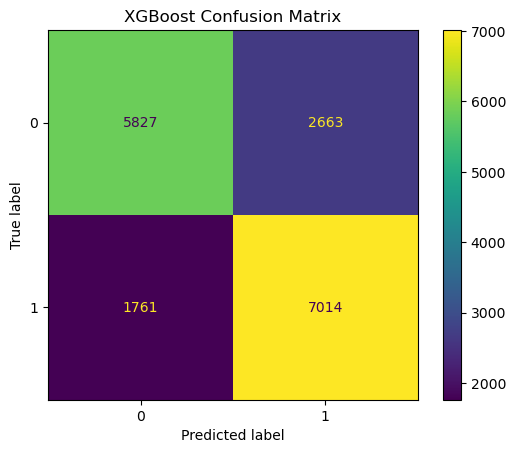

In [21]:
model.fit(xtrain, ytrain)
ConfusionMatrixDisplay.from_estimator(model, xtest, ytest)   #????????
plt.title("XGBoost Confusion Matrix")
plt.show()

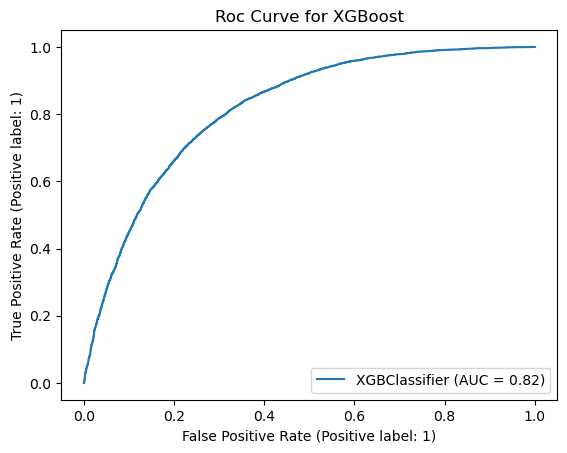

In [22]:
RocCurveDisplay.from_estimator(model, xtest, ytest) 
plt.title ("Roc Curve for XGBoost")

plt.show()

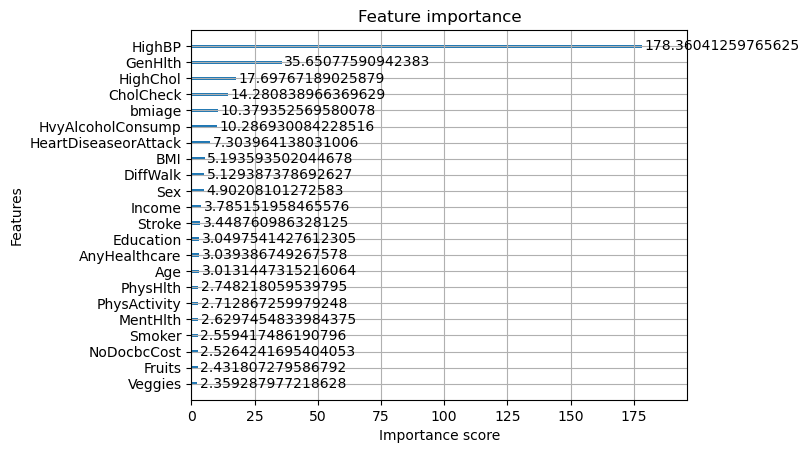

In [23]:
from xgboost import plot_importance
plot_importance(model, importance_type='gain')
plt.show()

In [24]:

scores2 = cross_val_score(model2, xtest, ytest, cv = kf)
accuracy2 = cross_val_score(model2, xtest, ytest, cv=kf, scoring='accuracy')
precision2 = cross_val_score(model2, xtest, ytest, cv=kf, scoring='precision')
recall2 = cross_val_score(model2, xtest, ytest, cv=kf, scoring='recall')
f12 = cross_val_score(model2, xtest, ytest, cv=kf, scoring='f1')

print ("Accuracy: ", accuracy2)
print ("precision: ", precision2)
print("recall: ", recall)
print("f1 Score: ", f12)

Accuracy:  [0.73537927 0.74001158 0.74638101 0.72379849 0.71858715 0.73059096
 0.73986095 0.73812283 0.73406721 0.72711472]
precision:  [0.72984749 0.73856209 0.74944072 0.71549894 0.708061   0.72052402
 0.72263549 0.72987872 0.73152174 0.72118551]
recall:  [0.78921382 0.78161793 0.80889058 0.78989362 0.78039514 0.79597264
 0.78381459 0.78419453 0.8081307  0.77963526]
f1 Score:  [0.7616951  0.74917127 0.75367232 0.73684211 0.73568282 0.73643411
 0.73219216 0.7452514  0.74496644 0.73905817]


In [25]:
model2.fit(xtrain, ytrain)

RandomForestClassifier(n_estimators=60)

In [26]:
#clean up, don' think I nwws this
model2.score(xtest, ytest)

0.7306689834926151

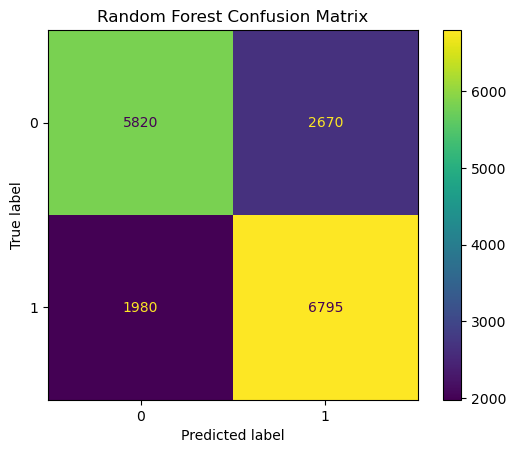

In [27]:
ConfusionMatrixDisplay.from_estimator(model2, xtest, ytest)   #???????? confusions comes from the test
plt.title("Random Forest Confusion Matrix")
plt.show()

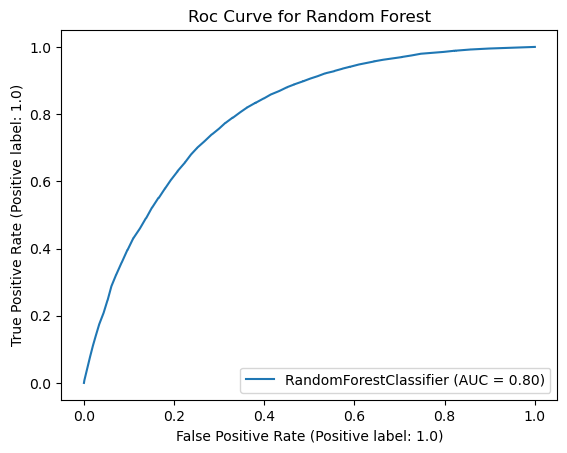

In [28]:
RocCurveDisplay.from_estimator(model2, xtest, ytest) 
plt.title ("Roc Curve for Random Forest")

plt.show()

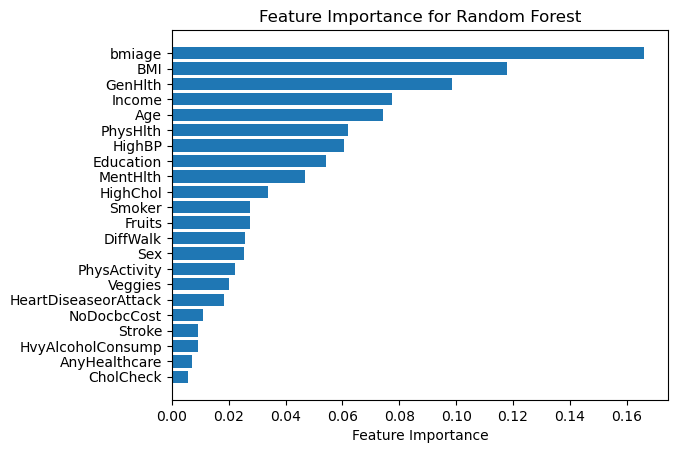

In [29]:
#feature importance come from the training???????????????????????????/
FeatureImportance = model2.feature_importances_
FeatureNames = xtrain.columns
indx = np.argsort(FeatureImportance)
plt.barh(FeatureNames[indx], FeatureImportance[indx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Random Forest')
plt.show()